In [8]:
"""
1D F_N sweep — model centroid / Shannon / slope vs Cariaco obs distribution.

Two-step workflow matching run_2d_stabilityscan-Scan5_restart.py:

  Step 1: parallel IVP parscan over F_N with model_setup_slim, reduced
          to tail-mean via the canned avg_tail postprocess.
  Step 2: parallel stability parscan over the same F_N grid with
          model_setup_stability, seeded per-cell from Step-1's tail-mean
          via extract_steady_state_seed.

Per-cell phyto centroid / Shannon / nbss_slope are extracted from the
stability output at time=-1 (the solved steady state) via
compute_phyto_spectrum_metrics on the 3 Cariaco phyto bins. Background
scatter = Cariaco monthly obs centroid distribution; horizontal bands =
obs envelope IQR.
"""

import os
import multiprocessing as mp

# macOS fork-safety, matching run_2d_stabilityscan-Scan5_restart.py
os.environ['OBJC_DISABLE_INITIALIZE_FORK_SAFETY'] = 'YES'
try:
    mp.set_start_method('fork', force=True)
    print(f"Start method: {mp.get_start_method()}")
except RuntimeError as e:
    print(f"Error: {e}")

import sys
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))   # parscan_utils, cariaco_obs in cwd
# (If running from plots/ instead of parameter_scan/, replace '.' with
#  '../parameter_scan' as in PlotFluxSpectrum.py.)

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets, DEFAULT_CSV_PATH
from parscan_utils import (
    aggregate_model_to_targets,
    compute_phyto_spectrum_metrics,
    extract_steady_state_seed,
)
from xso.parscans import run_xso_parscan, run_xso_stabilityscan


# -----------------------------------------------------------------------------
# 1. Setup — regime forcing, scan range
# -----------------------------------------------------------------------------
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)
print(f"Regime forcing (regime='{REGIME}'):")
print(f"  Inflow__FN = {forcing['Inflow__FN']:.4f}  (regime mean — replaced by scan)")
print(f"  Inflow__de = {forcing['Inflow__de']:.2f}  m  (held fixed)")

# F_N becomes the scan axis — pop it from forcing so it doesn't collide.
# d_e stays in forcing as the held-fixed box-geometry parameter. Add any
# previously-tuned parameters here before passing forcing to fixed_overrides,
# matching the In[3] pattern from run_2d_stabilityscan-Scan5.
forcing.pop('Inflow__FN', None)
# Example (uncomment / add as needed):
# forcing['GGE__gge']                 = 0.17416
# forcing['GGE__f_egest_D']           = 0.55602
# forcing['DetritusRemin__k_remin']   = 0.07590
# forcing['PhytoMortality__f_mort_D'] = 0.47651

# Scan range — log-spaced to resolve the low-F_N curvature where the model
# is most sensitive. Brackets observed F_N (~0.1 to ~12) with headroom.
P1_NAME     = 'Inflow__FN'
P1_LABEL    = 'New nutrient flux F_N (mmol N m⁻² d⁻¹)'
F_N_VALUES  = np.linspace(0.1, 25, 150) #np.logspace(np.log10(0.1), np.log10(25.0), 30)
N_PROCESSES = 8     # tune to your machine
AVG_WINDOW  = 1000

# Centroid only needs the 3 phyto bins, so filter to avoid
# aggregate_model_to_targets requiring pp / export / zoo entries.
phyto_bin_defs = [b for b in bin_defs if b['type'] == 'phyto']


# -----------------------------------------------------------------------------
# 2. Step 1 — IVP parscan over F_N (uses model_setup_slim)
# -----------------------------------------------------------------------------
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name=P1_NAME,
    param_values=F_N_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': AVG_WINDOW},
)


# -----------------------------------------------------------------------------
# 3. Step 2 — Stability parscan, seeded from Step-1 tail-means
# -----------------------------------------------------------------------------
seed_ds, iv_map = extract_steady_state_seed(scan_results, avg_window=AVG_WINDOW)

stability_results = run_xso_stabilityscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name=P1_NAME,
    param_values=F_N_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
    initial_values_ds=seed_ds,
    iv_mapping=iv_map,
)


# -----------------------------------------------------------------------------
# 4. Extract per-F_N metrics from stability output (time=-1 = solved SS)
# -----------------------------------------------------------------------------
n_FN = stability_results.sizes[P1_NAME]

centroid_model  = np.full(n_FN, np.nan)
shannon_model   = np.full(n_FN, np.nan)
slope_model     = np.full(n_FN, np.nan)
fractions_model = np.full((n_FN, 3), np.nan)
stability_label = np.full(n_FN, '', dtype=object)
max_eig_real    = np.full(n_FN, np.nan)

# fsolve floating-point noise hygiene, matching compute_cost_grid in Scan5:
NEG_TOL = 1e-6

for i in range(n_FN):
    p = stability_results.Phytoplankton__biomass.isel({P1_NAME: i, 'time': -1}).values
    z = stability_results.Zooplankton__biomass.isel({P1_NAME: i, 'time': -1}).values
    n = float(stability_results.Nutrient__value.isel({P1_NAME: i, 'time': -1}).values)
    d = float(stability_results.Detritus__value.isel({P1_NAME: i, 'time': -1}).values)

    if not (np.all(np.isfinite(p)) and np.all(np.isfinite(z))
            and np.isfinite(n) and np.isfinite(d)):
        continue
    if (np.any(p < -NEG_TOL) or np.any(z < -NEG_TOL)
            or n < -NEG_TOL or d < -NEG_TOL):
        continue
    p = np.clip(p, 0.0, None)
    z = np.clip(z, 0.0, None)

    model_state = {
        'phyto': p, 'zoo': z,
        'nutrient': max(n, 0.0), 'detritus': max(d, 0.0),
    }
    model_vec = aggregate_model_to_targets(
        model_state, phyto_esd, zoo_esd, phyto_bin_defs,
    )
    metrics = compute_phyto_spectrum_metrics(model_vec, phyto_bin_defs)
    centroid_model[i]  = metrics['centroid']
    shannon_model[i]   = metrics['shannon']
    slope_model[i]     = metrics['nbss_slope']
    fractions_model[i] = metrics['fractions']

    if 'stability' in stability_results:
        stability_label[i] = str(stability_results.stability.isel({P1_NAME: i}).values)
    if 'max_eigenvalue' in stability_results:
        max_eig_real[i] = float(stability_results.max_eigenvalue.isel({P1_NAME: i}).values)


# -----------------------------------------------------------------------------
# 5. Load Cariaco obs centroid scatter for the background overlay
# -----------------------------------------------------------------------------
obs_df = pd.read_csv(DEFAULT_CSV_PATH)
obs_df = obs_df.dropna(subset=['size_centroid', 'FN_mmolN_m2_d'])
print(f"\nCariaco obs months with centroid + F_N: {len(obs_df)}")

obs_centroid_med = obs_df['size_centroid'].median()
obs_centroid_q25 = obs_df['size_centroid'].quantile(0.25)
obs_centroid_q75 = obs_df['size_centroid'].quantile(0.75)
obs_centroid_max = obs_df['size_centroid'].max()

Start method: fork
Regime forcing (regime='all'):
  Inflow__FN = 2.6834  (regime mean — replaced by scan)
  Inflow__de = 45.58  m  (held fixed)
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_slim' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 150 points using 8 workers...
1D Scan complete. Time taken: 44.96175 seconds.
--- Starting Stability Scan ---
Validating model 'model' and setup 'model_setup_stability' from 'cariaco_ssm_setup'...
Validation successful. Proceeding with scan.
Injecting initial values from dataset using mapping: {'Nutrient__value': 'Nutrient__value_init', 'Phytoplankton__biomass': 'Phytoplankton__biomass_init', 'Zooplankton__biomass': 'Zooplankton__biomass_init', 'Detritus__value': 'Detritus__value_init'}
--------------------------------
Starting 1D stability scan of 'cariaco_ssm_set

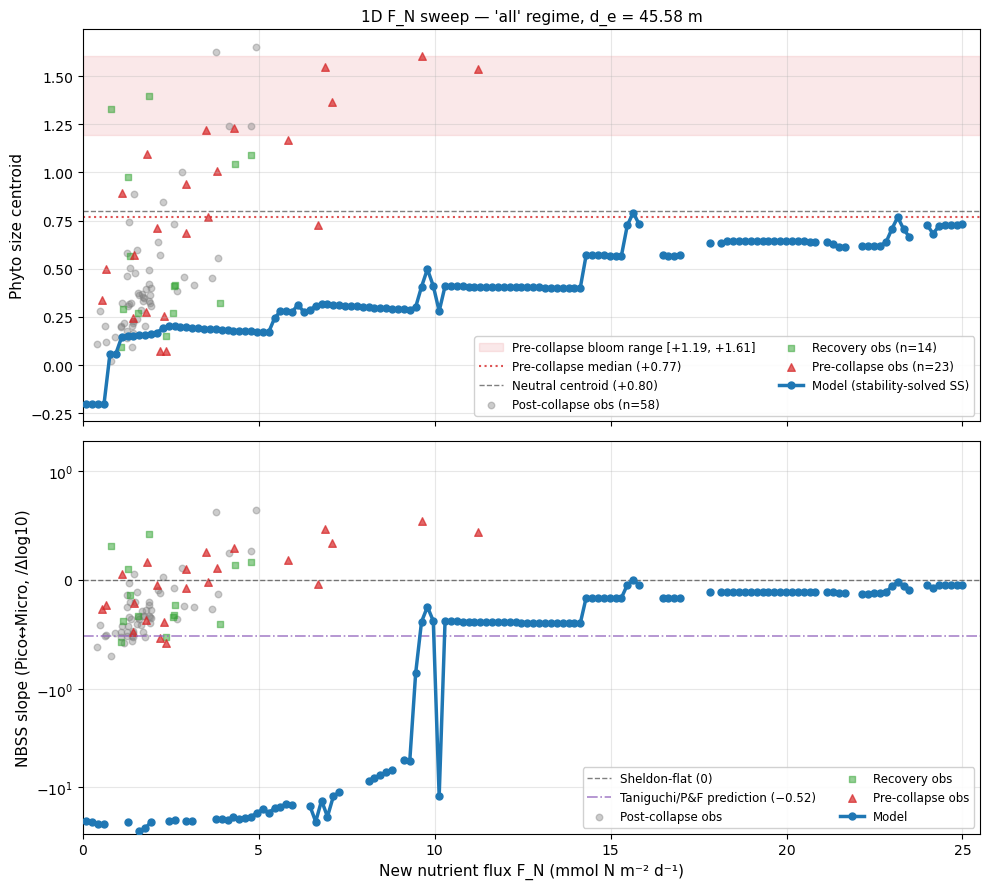

In [9]:
# -----------------------------------------------------------------------------
# 6. Plot — focused on model vs obs centroid/slope comparison
# -----------------------------------------------------------------------------
# Era-separate obs for visual emphasis on bloom-state (pre-collapse) months
obs_df['date_dt'] = pd.to_datetime(obs_df['date'])
era_pre  = obs_df[obs_df['date_dt'] <  pd.Timestamp('2005-01-01')]
era_post = obs_df[(obs_df['date_dt'] >= pd.Timestamp('2005-01-01')) &
                  (obs_df['date_dt'] <  pd.Timestamp('2014-01-01'))]
era_rec  = obs_df[obs_df['date_dt'] >= pd.Timestamp('2014-01-01')]

pre_med = era_pre['size_centroid'].median()
pre_q75 = era_pre['size_centroid'].quantile(0.75)
pre_max = era_pre['size_centroid'].max()

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# --- centroid panel ---
ax = axes[0]

# Pre-collapse bloom target — the centroid range the model must reach
ax.axhspan(pre_q75, pre_max, color='C3', alpha=0.10,
           label=f'Pre-collapse bloom range [+{pre_q75:.2f}, +{pre_max:.2f}]')
ax.axhline(pre_med, color='C3', ls=':', lw=1.5, alpha=0.8,
           label=f'Pre-collapse median (+{pre_med:.2f})')
ax.axhline(0.80, color='k', ls='--', lw=1, alpha=0.5,
           label='Neutral centroid (+0.80)')

# Era-separated obs scatter; pre-collapse on top with bigger markers
ax.scatter(era_post['FN_mmolN_m2_d'], era_post['size_centroid'],
           alpha=0.4, c='gray', s=22, marker='o',
           label=f'Post-collapse obs (n={len(era_post)})')
ax.scatter(era_rec['FN_mmolN_m2_d'], era_rec['size_centroid'],
           alpha=0.5, c='C2', s=22, marker='s',
           label=f'Recovery obs (n={len(era_rec)})')
ax.scatter(era_pre['FN_mmolN_m2_d'], era_pre['size_centroid'],
           alpha=0.7, c='C3', s=30, marker='^',
           label=f'Pre-collapse obs (n={len(era_pre)})')

# Model curve
ax.plot(F_N_VALUES, centroid_model, '-', color='C0', lw=2.5,
        marker='o', ms=5, label='Model (stability-solved SS)', zorder=5)

ax.set_ylabel('Phyto size centroid', fontsize=11)
ax.set_xlim(0, F_N_VALUES.max() * 1.02)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_title(f"1D F_N sweep — '{REGIME}' regime, d_e = {forcing['Inflow__de']:.2f} m",
             fontsize=11)

# --- slope panel ---
ax = axes[1]

# Reference lines first so the legend doesn't get overwhelmed
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5, label='Sheldon-flat (0)')
ax.axhline(-0.52, color='C4', ls='-.', lw=1.2, alpha=0.8,
           label='Taniguchi/P&F prediction (−0.52)')

if 'nbss_slope' in obs_df.columns:
    obs_slope = obs_df.dropna(subset=['nbss_slope']).copy()
    obs_slope['date_dt'] = pd.to_datetime(obs_slope['date'])
    sl_pre  = obs_slope[obs_slope['date_dt'] <  pd.Timestamp('2005-01-01')]
    sl_post = obs_slope[(obs_slope['date_dt'] >= pd.Timestamp('2005-01-01')) &
                        (obs_slope['date_dt'] <  pd.Timestamp('2014-01-01'))]
    sl_rec  = obs_slope[obs_slope['date_dt'] >= pd.Timestamp('2014-01-01')]
    ax.scatter(sl_post['FN_mmolN_m2_d'], sl_post['nbss_slope'],
               alpha=0.4, c='gray', s=22, marker='o', label='Post-collapse obs')
    ax.scatter(sl_rec['FN_mmolN_m2_d'], sl_rec['nbss_slope'],
               alpha=0.5, c='C2', s=22, marker='s', label='Recovery obs')
    ax.scatter(sl_pre['FN_mmolN_m2_d'], sl_pre['nbss_slope'],
               alpha=0.7, c='C3', s=30, marker='^', label='Pre-collapse obs')

ax.plot(F_N_VALUES, slope_model, '-', color='C0', lw=2.5,
        marker='o', ms=5, label='Model', zorder=5)

# Symlog y-scale: linear from -1 to +1, log beyond. Keeps obs visible
# linearly and the extreme model slopes visible-but-compressed.
ax.set_yscale('symlog', linthresh=1.0)
ax.set_ylim(-30, 2)

ax.set_xlabel(P1_LABEL, fontsize=11)
ax.set_ylabel('NBSS slope (Pico↔Micro, /Δlog10)', fontsize=11)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [11]:
print("\n=== Model centroid vs Cariaco bloom-state target ===")
if not np.all(np.isnan(centroid_model)):
    idx_max = int(np.nanargmax(centroid_model))
    model_max = centroid_model[idx_max]
    print(f"Model centroid range: "
          f"[{np.nanmin(centroid_model):+.3f}, {model_max:+.3f}]")
    print(f"Max model centroid {model_max:+.3f} reached at "
          f"F_N = {F_N_VALUES[idx_max]:.2f}")
    print(f"\nPre-collapse bloom target:")
    print(f"  median:    +{pre_med:.3f}")
    print(f"  Q75–max:   [+{pre_q75:.3f}, +{pre_max:.3f}]")
    print(f"\n→ Model max ({model_max:+.3f}) "
          f"{'REACHES' if model_max >= pre_q75 else 'does NOT reach'} "
          f"the pre-collapse bloom range "
          f"(Q75 = +{pre_q75:.3f}) within scanned F_N ≤ {F_N_VALUES.max():.1f}")
    if model_max < pre_max:
        print(f"  Gap to pre-collapse max: {pre_max - model_max:+.3f} centroid units")


=== Model centroid vs Cariaco bloom-state target ===
Model centroid range: [-0.201, +0.791]
Max model centroid +0.791 reached at F_N = 15.64

Pre-collapse bloom target:
  median:    +0.770
  Q75–max:   [+1.193, +1.606]

→ Model max (+0.791) does NOT reach the pre-collapse bloom range (Q75 = +1.193) within scanned F_N ≤ 25.0
  Gap to pre-collapse max: +0.816 centroid units


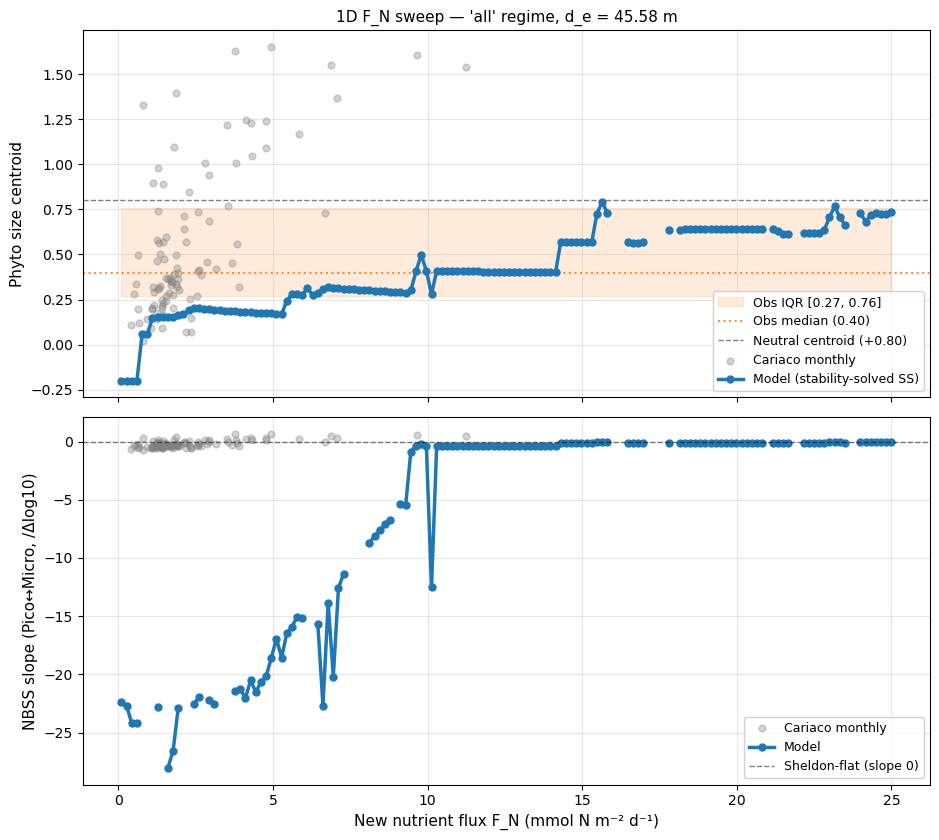


=== Model centroid vs Cariaco obs (stability-solved steady states) ===
Model centroid range: [-0.201, +0.791]
Max model centroid +0.791 reached at F_N = 15.64
Model centroid at obs-regime-mean F_N (2.38): +0.199
Obs centroid: median=+0.397, IQR=[+0.270, +0.756], max=+1.650
Model centroid never crosses obs median in scan range

Stability: 55/150 cells flagged 'stable'; max-eig range [-4.43e-03, 3.59e-02]


In [10]:

# -----------------------------------------------------------------------------
# 6. Plot — log F_N axis matching the log-spaced scan
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.5), sharex=True)

ax = axes[0]
ax.fill_between(F_N_VALUES, obs_centroid_q25, obs_centroid_q75,
                color='C1', alpha=0.15,
                label=f'Obs IQR [{obs_centroid_q25:.2f}, {obs_centroid_q75:.2f}]')
ax.axhline(obs_centroid_med, color='C1', ls=':', lw=1.5, alpha=0.85,
           label=f'Obs median ({obs_centroid_med:.2f})')
ax.axhline(0.80, color='k', ls='--', lw=1, alpha=0.5,
           label='Neutral centroid (+0.80)')
ax.scatter(obs_df['FN_mmolN_m2_d'], obs_df['size_centroid'],
           alpha=0.35, c='gray', s=24, label='Cariaco monthly')
ax.plot(F_N_VALUES, centroid_model, '-', color='C0', lw=2.5,
        marker='o', ms=5, label='Model (stability-solved SS)')
ax.set_ylabel('Phyto size centroid', fontsize=11)
#ax.set_xscale('log')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')
ax.set_title(f"1D F_N sweep — '{REGIME}' regime, d_e = {forcing['Inflow__de']:.2f} m",
             fontsize=11)

ax = axes[1]
if 'nbss_slope' in obs_df.columns:
    obs_slope = obs_df.dropna(subset=['nbss_slope'])
    ax.scatter(obs_slope['FN_mmolN_m2_d'], obs_slope['nbss_slope'],
               alpha=0.35, c='gray', s=24, label='Cariaco monthly')
ax.plot(F_N_VALUES, slope_model, '-', color='C0', lw=2.5,
        marker='o', ms=5, label='Model')
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5,
           label='Sheldon-flat (slope 0)')
ax.set_xlabel(P1_LABEL, fontsize=11)
ax.set_ylabel('NBSS slope (Pico↔Micro, /Δlog10)', fontsize=11)
#ax.set_yscale('log')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 7. Summary
# -----------------------------------------------------------------------------
print("\n=== Model centroid vs Cariaco obs (stability-solved steady states) ===")
if not np.all(np.isnan(centroid_model)):
    idx_max = int(np.nanargmax(centroid_model))
    print(f"Model centroid range: "
          f"[{np.nanmin(centroid_model):+.3f}, {np.nanmax(centroid_model):+.3f}]")
    print(f"Max model centroid {centroid_model[idx_max]:+.3f} reached at "
          f"F_N = {F_N_VALUES[idx_max]:.2f}")

    regime_fn = float(monthly_df['FN_mmolN_m2_d'].mean()) \
        if 'FN_mmolN_m2_d' in monthly_df.columns \
        else float(obs_df['FN_mmolN_m2_d'].mean())
    print(f"Model centroid at obs-regime-mean F_N ({regime_fn:.2f}): "
          f"{np.interp(regime_fn, F_N_VALUES, centroid_model):+.3f}")

    print(f"Obs centroid: median={obs_centroid_med:+.3f}, "
          f"IQR=[{obs_centroid_q25:+.3f}, {obs_centroid_q75:+.3f}], "
          f"max={obs_centroid_max:+.3f}")
    fn_at_obs_median = (
        np.interp(obs_centroid_med, centroid_model, F_N_VALUES)
        if (centroid_model.min() <= obs_centroid_med <= centroid_model.max())
        else np.nan
    )
    if np.isfinite(fn_at_obs_median):
        print(f"F_N at which model centroid matches obs median: {fn_at_obs_median:.2f}")
    else:
        print("Model centroid never crosses obs median in scan range")

    if any(s for s in stability_label):
        n_stable = sum(1 for s in stability_label if s == 'stable')
        print(f"\nStability: {n_stable}/{n_FN} cells flagged 'stable'; "
              f"max-eig range [{np.nanmin(max_eig_real):.2e}, "
              f"{np.nanmax(max_eig_real):.2e}]")
else:
    print("All scan cells failed — check scan output.")